# **Vishing DETECTION USING MACHINE LEARNING AND AI**

# **Import All Library**

In [1]:
import os
import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import RFE, SelectKBest, chi2
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from tensorflow.keras.layers import (
    Conv1D,
    Dense,
    Dropout,
    Embedding,
    GlobalMaxPooling1D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# --- Random Config ---
RANDOM_STATE = 24  # 19 24
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


# **Load Dataset**

In [2]:
# ==========================================
DATASET_FOLDER = 'fyp1_dataset' 
SCAM_FILENAME = 'English_Scam.txt'
NONSCAM_FILENAME = 'English_NonScam.txt'
CSV_FILENAME = "English_80dataset_cleaned.csv"

In [3]:
def load_and_clean_data(filename, label, folder=None, show_messages=False):
    cleaned_texts = []
    filepath = os.path.join(folder, filename) if folder else filename
    
    if not os.path.exists(filepath):
        print(f"ERROR: Could not find file at: {filepath}")
        return pd.DataFrame()

    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        for line in lines:
            if not line.strip():
                continue
            
            clean_line = re.sub(r'\\', '', line)
            clean_line = re.sub(r'^\s*\d+\.\s*', '', clean_line)
            clean_line = clean_line.strip()

            if clean_line:
                cleaned_texts.append(clean_line)

        df = pd.DataFrame(cleaned_texts, columns=['message'])
        df['label'] = label
        print(f"   -> Loaded {len(df)} rows from {filename}")
        return df

    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return pd.DataFrame()

def load_csv_dataset_simple(filename, folder=None):
    filepath = os.path.join(folder, filename) if folder else filename

    if not os.path.exists(filepath):
        print(f"ERROR: Could not find CSV at: {filepath}")
        return pd.DataFrame()

    df = pd.read_csv(filepath)

    # Rename text -> message (so it matches other dfs)
    if "text" not in df.columns or "label" not in df.columns:
        raise ValueError(f"CSV must contain columns ['text','label']. Found: {df.columns.tolist()}")

    df = df.rename(columns={"text": "message"})

    label_map = {
        "NonPhishing": 0,
        "Phishing": 1,
        "NonScam": 0,   
        "Scam": 1
    }

    df["label"] = df["label"].astype(str).str.strip()
    df["label"] = df["label"].map(label_map)

    # Drop anything unknown/unmapped
    df = df.dropna(subset=["message", "label"])
    df["label"] = df["label"].astype(int)

    df["message"] = df["message"].astype(str).str.strip()
    df = df[df["message"] != ""]

    print(f"   -> Loaded {len(df)} rows from {filename}")
    return df

In [4]:
# 1) Load TXT datasets
scam_df = load_and_clean_data(SCAM_FILENAME, 1, folder=DATASET_FOLDER)
nonscam_df = load_and_clean_data(NONSCAM_FILENAME, 0, folder=DATASET_FOLDER)

# 2) Load CSV dataset
extra_df = load_csv_dataset_simple(CSV_FILENAME, folder=DATASET_FOLDER)

# 3) Add CSV rows into scam_df and nonscam_df
scam_df = pd.concat([scam_df, extra_df[extra_df["label"] == 1]], ignore_index=True)
nonscam_df = pd.concat([nonscam_df, extra_df[extra_df["label"] == 0]], ignore_index=True)

print("scam_df size:", scam_df.shape)
print("nonscam_df size:", nonscam_df.shape)





   -> Loaded 400 rows from English_Scam.txt
   -> Loaded 400 rows from English_NonScam.txt
   -> Loaded 80 rows from English_80dataset_cleaned.csv
scam_df size: (440, 2)
nonscam_df size: (440, 2)


# **Feature Extraction**



## **1. Splitting Data**

In [5]:
test_scam = scam_df.sample(n=176)
test_nonscam = nonscam_df.sample(n=176)

train_scam = scam_df.drop(test_scam.index)
train_nonscam = nonscam_df.drop(test_nonscam.index)

train_data = pd.concat([train_scam, train_nonscam], ignore_index=True)
test_data = pd.concat([test_scam, test_nonscam], ignore_index=True)

# Shuffle training data
train_data = train_data.sample(frac=1).reset_index(drop=True)

### **Data split Result**

In [6]:
print(f"Train Size: {len(train_data)}")
print(f"Test Size:  {len(test_data)}")

print("\nTrain label count:")
print(train_data["label"].value_counts())

print("\nTest label count:")
print(test_data["label"].value_counts())

print("\nTrain Data (first 10 rows):")
print(train_data.head(10))

print("\nTest Data (first 10 rows):")
print(test_data.head(10))

Train Size: 528
Test Size:  352

Train label count:
label
0    264
1    264
Name: count, dtype: int64

Test label count:
label
1    176
0    176
Name: count, dtype: int64

Train Data (first 10 rows):
                                             message  label
0  [Greetings], this is [Company] Bank Customer S...      0
1  [Greetings], this is [Company]  calling to inf...      1
2  Congratulations on your first successful inves...      1
3  [Greetings], this is [Name], and we are from [...      1
4  [Greetings], this is [Name] from [Company] Tra...      0
5  [Greetings], this is [Name]. I know you have b...      0
6  [Greetings], it is [Name] from [Company]  Trav...      1
7  [Greetings], this is [Name] from [Company]. We...      1
8  [Greetings], this is [Title][Name] from the po...      0
9  [Greetings], this is [Name]. I noticed we have...      0

Test Data (first 10 rows):
                                             message  label
0  [Greetings] [Name]! Greetings from the Chinese...

## **Tokenization For Deep learning**

### **Normalize dataset**

In [7]:
def normalize_placeholders(text):
    # Combined pattern:
    # \[.*?\] -> Matches bracketed text like [Name]
    # \d{1,2}:\d{2}\s*(?:AM|PM|am|pm) -> Matches like 10:00AM
    pattern = r"\[.*?\]|\b\d{1,2}:\d{2}\s*(?:AM|PM|am|pm)\b"
    
    return re.sub(pattern, "<PLACEHOLDER>", text)
    # change all personal data or name to <PLACEHOLDER>

In [8]:
train_data["message"] = train_data["message"].apply(normalize_placeholders)
test_data["message"]  = test_data["message"].apply(normalize_placeholders)

### **Tokenization**

In [9]:
# Config ============
vocab_size = 3000
embedding_dim = 16
max_length = 30
trunc_type = "post"
padding_type = "post"
oov_tok = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_data["message"])   # ✅ fit ONLY on training text

# Convert text -> sequences
X_train_seq = tokenizer.texts_to_sequences(train_data["message"])
X_test_seq  = tokenizer.texts_to_sequences(test_data["message"])

# Pad sequences
X_train = pad_sequences(X_train_seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)
X_test  = pad_sequences(X_test_seq,  maxlen=max_length, padding=padding_type, truncating=trunc_type)

# Labels
y_train = train_data["label"].values
y_test  = test_data["label"].values

In [10]:
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

print("\n📝 Example original:", train_data["message"].iloc[0])
print("Example seq:     ", X_train_seq[0][:30])
print("Example padded:  ", X_train[0][:30])

X_train shape: (528, 30)
X_test shape:  (352, 30)
y_train shape: (528,)
y_test shape:  (352,)

📝 Example original: <PLACEHOLDER>, this is <PLACEHOLDER> Bank Customer Support. We are calling to confirm a few recent changes to your account preferences. Is now a good time to walk through them together?
Example seq:      [2, 10, 6, 2, 37, 545, 132, 11, 15, 71, 3, 72, 7, 292, 104, 467, 3, 4, 23, 1095, 6, 39, 7, 247, 55, 3, 321, 88, 680, 98]
Example padded:   [   2   10    6    2   37  545  132   11   15   71    3   72    7  292
  104  467    3    4   23 1095    6   39    7  247   55    3  321   88
  680   98]


## **TF-IDF Feature Extraction For Machine Learning**

### **Step1: Extract words - TF-IDF**

In [11]:
my_stop_words = list(text.ENGLISH_STOP_WORDS) + ["placeholder"]

# --- 2. CONFIGURATION ---
vectorizer = TfidfVectorizer(
    stop_words=my_stop_words,
    max_features=700,
    ngram_range=(1, 2),
    
    min_df=1,              # Keep rare words
    max_df=0.80,
    sublinear_tf=True
)

# Fit on TRAIN, Transform TEST
train_tfidf = vectorizer.fit_transform(train_data["message"])
test_tfidf  = vectorizer.transform(test_data["message"])
    
y_train_tfidf = train_data["label"].values
y_test_tfidf  = test_data["label"].values

### **Step2: Dedupplicate**

Found 64 features to drop (|corr| > 0.95).


## High-Correlation Pairs (|corr| > 0.95)

Feature A,Feature B,Abs Corr
affiliate,sales,1.0000
affiliate marketing,sales,1.0000
account account,loan designated,1.0000
account account,properly,1.0000
account account,ensure properly,1.0000
account account,designated account,1.0000
affiliate,affiliate marketing,1.0000
account account,transfer loan,1.0000
allocate,allocate funds,1.0000
account account,properly allocated,1.0000


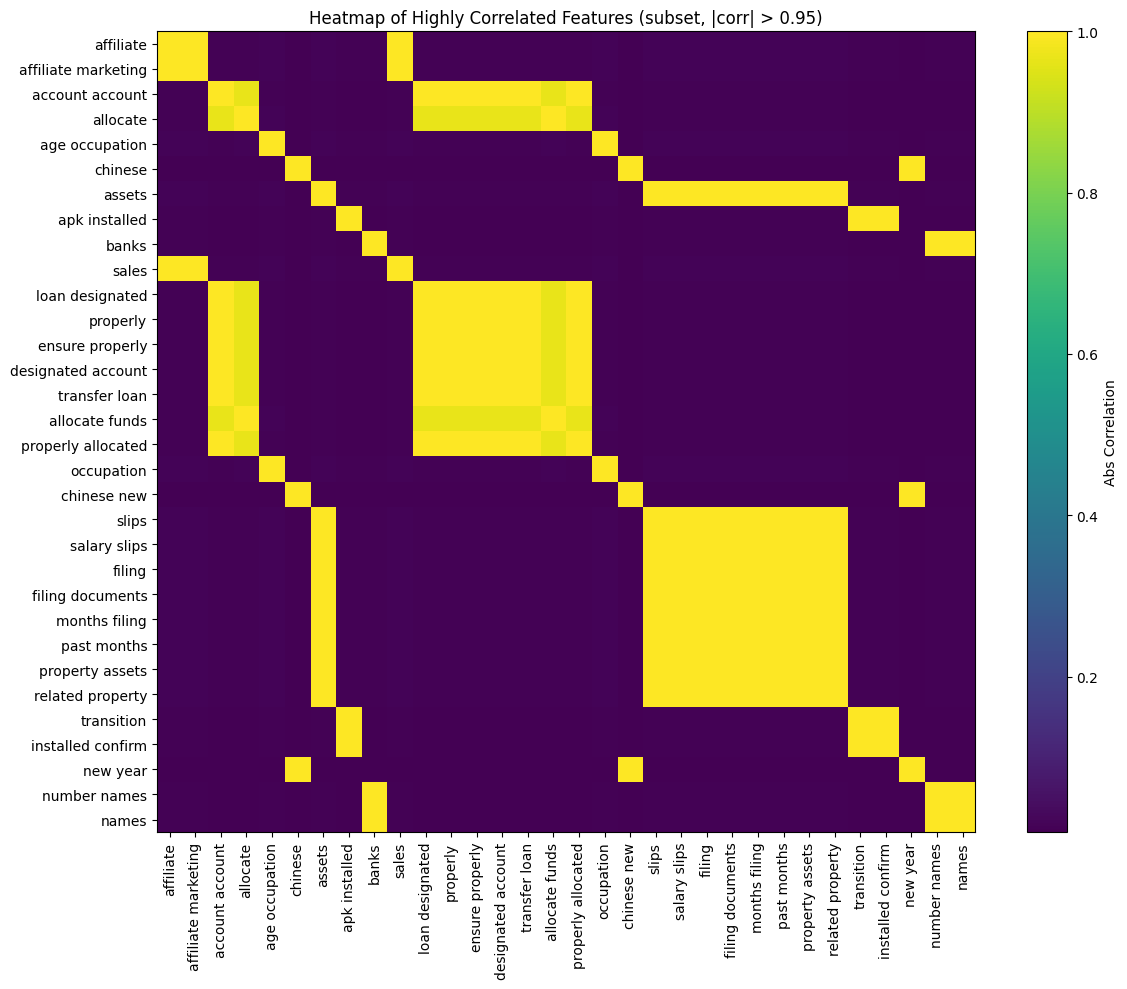

In [12]:
THRESH = 0.95

# 1) Build correlation matrix (TRAIN only)
feature_names = np.array(vectorizer.get_feature_names_out())
df_train = pd.DataFrame(train_tfidf.toarray(), columns=feature_names)

corr = df_train.corr().abs()

# 2) Upper triangle + find features to drop
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if (upper[col] > THRESH).any()]
print(f"Found {len(to_drop)} features to drop (|corr| > {THRESH}).")

# 3) Make ALL high-corr pairs table (for proof)
all_pairs = upper.stack()
dup_pairs = all_pairs[all_pairs > THRESH].sort_values(ascending=False)

pairs_df = dup_pairs.reset_index()
pairs_df.columns = ["Feature A", "Feature B", "Abs Corr"]

display(Markdown(f"## High-Correlation Pairs (|corr| > {THRESH})"))
display(pairs_df.head(30).style.format({"Abs Corr": "{:.4f}"}).hide(axis="index"))

# 4) Heatmap proof (subset: features in top pairs)
if len(pairs_df) > 0:
    top_pairs = pairs_df.head(25)
    feat_set = list(dict.fromkeys(top_pairs["Feature A"].tolist() + top_pairs["Feature B"].tolist()))
    sub = corr.loc[feat_set, feat_set]

    plt.figure(figsize=(12, 10)) 
    plt.imshow(sub.values, interpolation="nearest", aspect="auto") 
    plt.colorbar(label="Abs Correlation") 
    plt.xticks(range(len(feat_set)), feat_set, rotation=90)
    plt.yticks(range(len(feat_set)), feat_set) 
    plt.title(f"Heatmap of Highly Correlated Features (subset, |corr| > {THRESH})") 
    plt.tight_layout() 
    plt.show()

else:
    print("No highly correlated pairs found above threshold; skipping heatmap.")

# 5) Remove redundant features (keep sparse matrices)
kept_feature_mask = ~np.isin(feature_names, to_drop)

X_input_train = train_tfidf[:, kept_feature_mask]
X_input_test  = test_tfidf[:,  kept_feature_mask]
current_feature_names = feature_names[kept_feature_mask]


In [13]:
feature_names = vectorizer.get_feature_names_out()

df_train = pd.DataFrame(train_tfidf.toarray(), columns=feature_names)
df_test  = pd.DataFrame(test_tfidf.toarray(),  columns=feature_names)

corr_matrix = df_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"   Found {len(to_drop)} duplicates to drop.")

if len(to_drop) > 0:
    kept_feature_mask = ~np.isin(feature_names, to_drop)   # boolean mask (length = 700)
    current_feature_names = feature_names[kept_feature_mask]

    # keep sparse matrices (important for shape consistency in predict())
    X_input_train = train_tfidf[:, kept_feature_mask]
    X_input_test  = test_tfidf[:,  kept_feature_mask]
else:
    kept_feature_mask = np.ones(train_tfidf.shape[1], dtype=bool)
    current_feature_names = feature_names
    X_input_train = train_tfidf
    X_input_test  = test_tfidf

print(f"Deduplication Complete. Shape: {X_input_train.shape}")


   Found 64 duplicates to drop.
Deduplication Complete. Shape: (528, 636)


### **Step3: (Filter noise)Feature Selection using Chi-Square Test**

In [14]:
print("--- STARTING FEATURE SELECTION ---")
print(f"Original Feature Count: {train_tfidf.shape[1]}")

# 1. Chi-Square Filter (Fast reduction from 700 -> 500)
# use a slightly smaller number, max_features is 700
INITIAL_K = 500

# Safety Check: Only run if we have enough features
if X_input_train.shape[1] > INITIAL_K:
    print(f"   Running Chi-Square ({X_input_train.shape[1]} -> {INITIAL_K})...")
    chi2_selector = SelectKBest(chi2, k=INITIAL_K)
    
    # NOTE: We use X_input_train (the cleaned data), NOT train_tfidf (the raw data)
    X_train_chi = chi2_selector.fit_transform(X_input_train, y_train_tfidf)
    X_test_chi = chi2_selector.transform(X_input_test)
else:
    print(f"   Skipping Chi-Square (Features already < {INITIAL_K})")
    chi2_selector = None  # ✅ no chi2 filter applied
    X_train_chi = X_input_train
    X_test_chi = X_input_test

print(f"   Shape after Chi-Square: {X_train_chi.shape}")

print(f"Shape after Chi-Square: {X_train_chi.shape}")

--- STARTING FEATURE SELECTION ---
Original Feature Count: 700
   Running Chi-Square (636 -> 500)...
   Shape after Chi-Square: (528, 500)
Shape after Chi-Square: (528, 500)


In [15]:
print("--- STARTING FEATURE SELECTION ---")
print(f"Original Feature Count: {train_tfidf.shape[1]}")

INITIAL_K = 500

if X_input_train.shape[1] > INITIAL_K:
    print(f"   Running Chi-Square ({X_input_train.shape[1]} -> {INITIAL_K})...")
    chi2_selector = SelectKBest(chi2, k=INITIAL_K)

    X_train_chi = chi2_selector.fit_transform(X_input_train, y_train_tfidf)
    X_test_chi  = chi2_selector.transform(X_input_test)

    print(f"   Shape after Chi-Square: {X_train_chi.shape}")

    # ---- TABLE: Top Chi2 features (selected) ----
    display(Markdown("## Chi-Square: Top 20 Selected Features"))

    # feature names going into chi2 = current_feature_names (after dedup)
    chi2_in_features = np.array(current_feature_names)

    scores = chi2_selector.scores_
    pvals  = chi2_selector.pvalues_
    mask   = chi2_selector.get_support()

    df_chi2 = (
        pd.DataFrame({
            "Feature Name": chi2_in_features[mask],
            "Chi2 Score": scores[mask],
            "p-value": pvals[mask],
        })
        .sort_values("Chi2 Score", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

    display(df_chi2.style.format({"Chi2 Score": "{:.6f}", "p-value": "{:.3e}"}).hide(axis="index"))

else:
    print(f"   Skipping Chi-Square (Features already < {INITIAL_K})")
    chi2_selector = None
    X_train_chi = X_input_train
    X_test_chi  = X_input_test
    print(f"   Shape after Chi-Square: {X_train_chi.shape}")


--- STARTING FEATURE SELECTION ---
Original Feature Count: 700
   Running Chi-Square (636 -> 500)...
   Shape after Chi-Square: (528, 500)


## Chi-Square: Top 20 Selected Features

Feature Name,Chi2 Score,p-value
bank account,9.942545,1.615e-03
number,9.125074,2.521e-03
bank,8.293615,3.978e-03
know,8.256325,4.061e-03
want,7.247947,7.098e-03
like,7.099045,7.713e-03
account,6.845234,8.888e-03
recent,6.811900,9.055e-03
card,6.741554,9.419e-03
just,6.698937,9.647e-03


### **Step4: Rank Importance RFE (Recursive Feature Elimination)**

In [16]:
# 2. RFE Wrapper (Precise reduction from 500 -> 300)
# Uses a lightweight RF to find the absolute best features
print("\n--- 3. RFE SELECTION ---")
FINAL_K = 300
print(f"   Running RFE ({X_train_chi.shape[1]} -> {FINAL_K})...")

rf_estimator = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=RANDOM_STATE)
rfe_selector = RFE(estimator=rf_estimator, n_features_to_select=FINAL_K, step=50)

# Final Output Variables (Same names as your original code)
X_train_rfe = rfe_selector.fit_transform(X_train_chi, y_train_tfidf)
X_test_rfe = rfe_selector.transform(X_test_chi)

print(f"Feature Selection Complete. Final Shape: {X_train_rfe.shape}")


--- 3. RFE SELECTION ---
   Running RFE (500 -> 300)...
Feature Selection Complete. Final Shape: (528, 300)


### **Show Table Rank Importance RFE**

In [17]:
summary = pd.DataFrame({
    "Stage": ["Original TF-IDF", "After Chi-Square", "After RFE"],
    "No. of Features": [train_tfidf.shape[1], X_train_chi.shape[1], X_train_rfe.shape[1]],
})

summary

    

,Stage,No. of Features
0,Original TF-IDF,700
1,After Chi-Square,500
2,After RFE,300


# **Training Classification Model======================================**

## **1. Random Forest Model**

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight={0: 1, 1: 1},  # increase 1 to get more "Scam" predictions
    random_state=RANDOM_STATE,
)
rf_model.fit(train_tfidf, y_train_tfidf)


print("Model trained successfully!")

Model trained successfully!


## **2. SVM Model**

In [19]:
svm_model = SVC(
    kernel="linear",
    probability=True,
    C=0.1,
    class_weight={0: 1, 1: 1},
    random_state=RANDOM_STATE,
)

svm_model.fit(train_tfidf, y_train_tfidf)

print("SVM trained successfully")


SVM trained successfully


## **3.CNN MODEL**

In [20]:

CNNmodel = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [21]:
# --- Training Settings ---
num_epochs = 10
batch_size = 16
learning_rate = 0.001  

# --- Compile the Model ---

CNNmodel.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=learning_rate),
    metrics=['accuracy']
)



# --- Train the Model ---
class_weight = {0: 1.0, 1: 1}

history_cnn = CNNmodel.fit(
    X_train,
    y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    class_weight=class_weight,
    verbose=1
)

print("CNN Training Complete!")
# model.summary()

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5795 - loss: 0.6887 - val_accuracy: 0.8153 - val_loss: 0.6804
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7292 - loss: 0.6609 - val_accuracy: 0.7585 - val_loss: 0.6466
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7462 - loss: 0.6083 - val_accuracy: 0.7869 - val_loss: 0.5841
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8049 - loss: 0.5298 - val_accuracy: 0.8409 - val_loss: 0.4923
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8390 - loss: 0.4285 - val_accuracy: 0.8835 - val_loss: 0.3835
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9034 - loss: 0.2946 - val_accuracy: 0.9318 - val_loss: 0.2877
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8996 - loss: 0.2310 - val_accuracy: 0.9460 - val_loss: 0.2261
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9299 - loss: 0.1620 - val_accuracy: 0.9489 - val_loss

## **4. MLP Model**

In [22]:
learning_rate = 0.01  

MLPmodel = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    GlobalMaxPooling1D(),
    Dense(16, activation='relu'), 
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

MLPmodel.compile(loss='binary_crossentropy', 
                 optimizer=Adam(learning_rate=learning_rate), 
                 metrics=['accuracy']
                )

# --- TRAIN ---
num_epochs = 10 
print(f"\nTraining MLP for {num_epochs} epochs...")

class_weight = {0: 1.0, 1: 1}

history_mlp = MLPmodel.fit(
    X_train, y_train,
    epochs=num_epochs,
    validation_data=(X_test, y_test),
    class_weight=class_weight,
    verbose=1
)

print("MLP Training successfully!")


Training MLP for 10 epochs...
Epoch 1/10


C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5795 - loss: 0.6807 - val_accuracy: 0.8494 - val_loss: 0.6356
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7576 - loss: 0.5818 - val_accuracy: 0.8892 - val_loss: 0.4627
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8996 - loss: 0.3383 - val_accuracy: 0.9460 - val_loss: 0.2291
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9489 - loss: 0.1758 - val_accuracy: 0.9517 - val_loss: 0.1479
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9830 - loss: 0.0898 - val_accuracy: 0.9574 - val_loss: 0.1279
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.0507 - val_accuracy: 0.9631 - val_loss: 0.1210
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9905 - loss: 0.0461 - val_accuracy: 0.9574 - val_loss: 0.1190
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0283 - val_accuracy: 0.9631 - val_loss: 0.1170
Ep

# **Result======================================================**

## **1. Result for ML**

## **RF before feature selection**


TEST RESULTS
Test Accuracy: 93.47%

Classification Report:
               precision    recall  f1-score   support

Not Scam (0)       0.90      0.98      0.94       176
    Scam (1)       0.98      0.89      0.93       176

    accuracy                           0.93       352
   macro avg       0.94      0.93      0.93       352
weighted avg       0.94      0.93      0.93       352



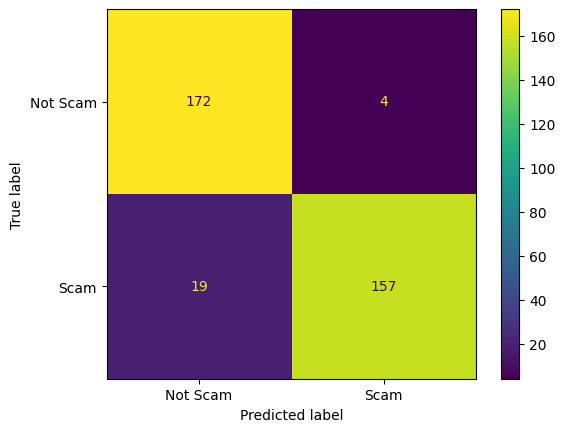

In [23]:
# 1) Predict on test
y_pred = rf_model.predict(test_tfidf)
cm = confusion_matrix(y_test_tfidf, y_pred)

# 2) Basic metrics
acc = accuracy_score(y_test_tfidf, y_pred)
print("\nTEST RESULTS")
print(f"Test Accuracy: {acc*100:.2f}%")

print("\nClassification Report:\n",
      classification_report(y_test_tfidf, y_pred, target_names=["Not Scam (0)", "Scam (1)"]))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Scam", "Scam"])
disp.plot(values_format="d")
plt.show()


## **RF after feature selection**

In [24]:
rf_model.fit(X_train_rfe, y_train_tfidf) # NEW

,n_estimators,300
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



--- MODEL PERFORMANCE RESULTS ---
Test Accuracy: 92.61%
              precision    recall  f1-score   support

    Non-Scam       0.89      0.97      0.93       176
        Scam       0.97      0.88      0.92       176

    accuracy                           0.93       352
   macro avg       0.93      0.93      0.93       352
weighted avg       0.93      0.93      0.93       352



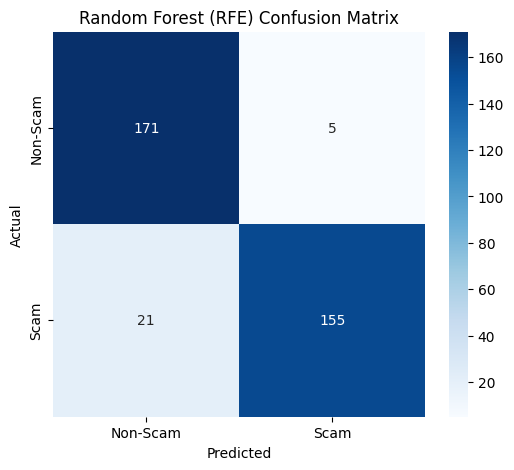

In [25]:
# 1. Predict on the Test Set (using the RFE-selected features)
y_pred = rf_model.predict(X_test_rfe)

# 2. Print Summary Statistics
print("\n--- MODEL PERFORMANCE RESULTS ---")
acc = accuracy_score(y_test_tfidf, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")

print(classification_report(y_test_tfidf, y_pred, target_names=['Non-Scam', 'Scam']))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_test_tfidf, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Scam', 'Scam'], 
            yticklabels=['Non-Scam', 'Scam'])
plt.title('Random Forest (RFE) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## **SVM before feature selection**

Test Accuracy: 95.45%

Classification Report:
               precision    recall  f1-score   support

Not Scam (0)       0.97      0.94      0.95       176
    Scam (1)       0.94      0.97      0.96       176

    accuracy                           0.95       352
   macro avg       0.95      0.95      0.95       352
weighted avg       0.95      0.95      0.95       352



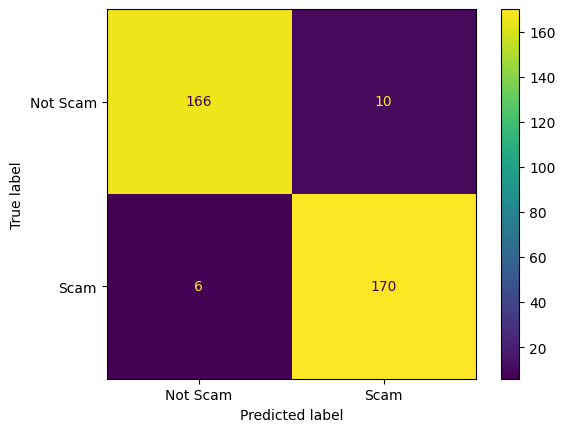

In [26]:
y_pred = svm_model.predict(test_tfidf)        

cm = confusion_matrix(y_test_tfidf, y_pred)
acc = accuracy_score(y_test_tfidf, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")

print("\nClassification Report:\n",
      classification_report(y_test_tfidf, y_pred, target_names=["Not Scam (0)", "Scam (1)"]))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Scam", "Scam"])
disp.plot(values_format="d")
plt.show()

## **SVM after feature selection**


--- MODEL PERFORMANCE RESULTS  ---
Test Accuracy: 96.31%
              precision    recall  f1-score   support

    Non-Scam       0.97      0.95      0.96       176
        Scam       0.96      0.97      0.96       176

    accuracy                           0.96       352
   macro avg       0.96      0.96      0.96       352
weighted avg       0.96      0.96      0.96       352



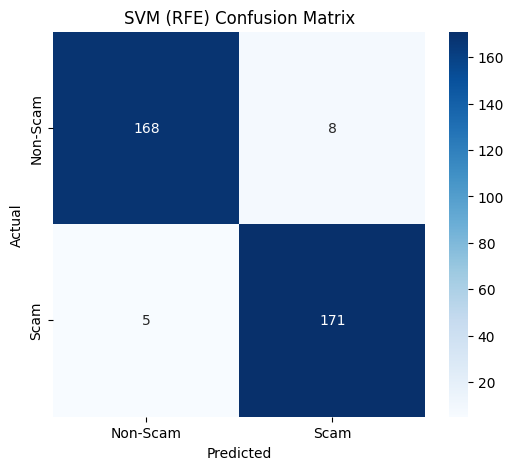

In [27]:
# Train a NEW SVM on RFE features (300)
svm_rfe = SVC(kernel="linear", C=1, random_state=RANDOM_STATE)
svm_rfe.fit(X_train_rfe, y_train_tfidf)

# Predict using RFE test features (300)
y_pred = svm_rfe.predict(X_test_rfe)

print("\n--- MODEL PERFORMANCE RESULTS  ---")
acc = accuracy_score(y_test_tfidf, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")
print(classification_report(y_test_tfidf, y_pred, target_names=['Non-Scam', 'Scam']))

cm = confusion_matrix(y_test_tfidf, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Scam', 'Scam'],
            yticklabels=['Non-Scam', 'Scam'])
plt.title('SVM (RFE) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## **2. Result for DL**

### **CNN**

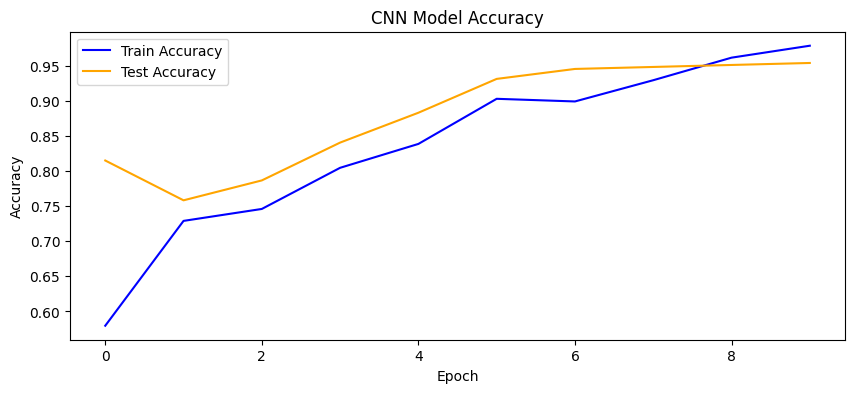


--- EVALUATION (CNN) ---
Final Accuracy: 95.45%

--- PERFORMANCE SUMMARY ---
              precision    recall  f1-score  Total Case
Non-Scam       0.959770  0.948864  0.954286       176.0
Scam           0.949438  0.960227  0.954802       176.0
accuracy       0.954545  0.954545  0.954545       352.0
macro avg      0.954604  0.954545  0.954544       352.0
weighted avg   0.954604  0.954545  0.954544       352.0


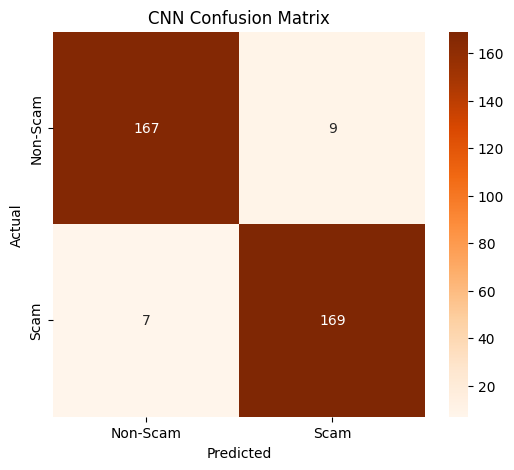

In [28]:
# --- 1. PLOT TRAINING HISTORY (CNN) ---
plt.figure(figsize=(10, 4))
# Note: Ensure you have 'history_cnn' from your training step
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_cnn.history['val_accuracy'], label='Test Accuracy', color='orange')
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# --- 2. PREDICT ---
print("\n--- EVALUATION (CNN) ---")
probs = CNNmodel.predict(X_test, verbose=0).ravel()
threshold = 0.55
y_pred = (probs >= threshold).astype(int)

# --- 3. PRINT ACCURACY ---
acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {acc*100:.2f}%")

# --- 4. PERFORMANCE TABLE (ADDED) ---
# Generate report as dictionary
report_dict = classification_report(y_test, y_pred, target_names=['Non-Scam', 'Scam'], output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

# Rename 'support' to 'Total Case'
df_report = df_report.rename(columns={'support': 'Total Case'})

# Fix the 'accuracy' row (which doesn't have support by default)
df_report.loc['accuracy', 'Total Case'] = len(y_test)
df_report.loc['accuracy', 'precision'] = acc
df_report.loc['accuracy', 'recall'] = acc
df_report.loc['accuracy', 'f1-score'] = acc

print("\n--- PERFORMANCE SUMMARY ---")
print(df_report[['precision', 'recall', 'f1-score', 'Total Case']])

# --- 5. CONFUSION MATRIX (ORANGE) ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Non-Scam', 'Scam'], 
            yticklabels=['Non-Scam', 'Scam'])
plt.title('CNN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### **MLP**

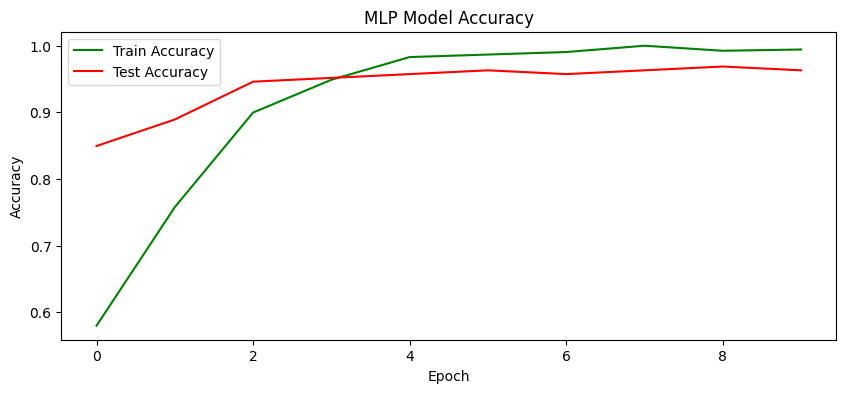


--- EVALUATION (MLP) ---
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Final Accuracy: 96.59%

--- PERFORMANCE SUMMARY ---
              precision    recall  f1-score  Total Case
Non-Scam       0.955556  0.977273  0.966292       176.0
Scam           0.976744  0.954545  0.965517       176.0
accuracy       0.965909  0.965909  0.965909       352.0
macro avg      0.966150  0.965909  0.965905       352.0
weighted avg   0.966150  0.965909  0.965905       352.0


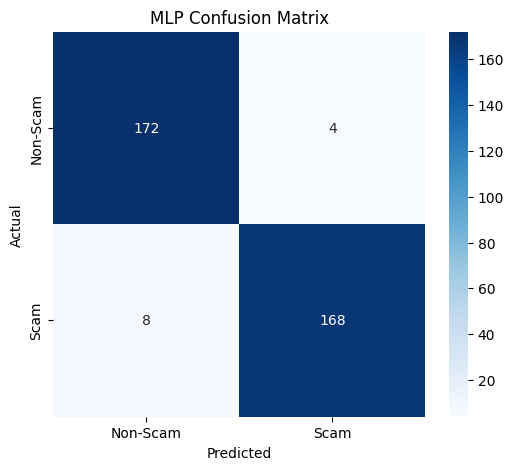

In [29]:
# --- 1. PLOT TRAINING HISTORY (MLP) ---
plt.figure(figsize=(10, 4))
# Note: Ensure you have 'history_mlp' from your training step
plt.plot(history_mlp.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history_mlp.history['val_accuracy'], label='Test Accuracy', color='red')
plt.title('MLP Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# --- 2. PREDICT ---
print("\n--- EVALUATION (MLP) ---")
predictions = MLPmodel.predict(X_test)
threshold = 0.55
y_pred = (predictions >= threshold).astype(int)

# --- 3. PRINT ACCURACY ---
acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {acc*100:.2f}%")

# --- 4. PERFORMANCE TABLE (ADDED) ---
# Generate report as dictionary
report_dict = classification_report(y_test, y_pred, target_names=['Non-Scam', 'Scam'], output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

# Rename 'support' to 'Total Case'
df_report = df_report.rename(columns={'support': 'Total Case'})

# Fix the 'accuracy' row
df_report.loc['accuracy', 'Total Case'] = len(y_test)
df_report.loc['accuracy', 'precision'] = acc
df_report.loc['accuracy', 'recall'] = acc
df_report.loc['accuracy', 'f1-score'] = acc

print("\n--- PERFORMANCE SUMMARY ---")
print(df_report[['precision', 'recall', 'f1-score', 'Total Case']])

# --- 5. CONFUSION MATRIX (BLUE) ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Scam', 'Scam'], 
            yticklabels=['Non-Scam', 'Scam'])
plt.title('MLP Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# **Custom Call Test**

In [30]:
# ==========================================
# 1. DEFINE PREDICTION FUNCTIONS
# ==========================================

def predict_cnn(text):
    # CNN uses Tokenizer + Padding
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)
    prob = CNNmodel.predict(padded)[0][0]
    if prob > 0.5:
        return "SCAM ", prob
    else:
        return "Safe ", (1 - prob)

def predict_mlp(text):
    # MLP uses Tokenizer + Padding
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)
    prob = MLPmodel.predict(padded)[0][0]
    if prob > 0.5:
        return "SCAM ", prob
    else:
        return "Safe ", (1 - prob)

def predict_rf(text):
    # RF uses Vectorizer + Chi2 + RFE (Strict Feature Selection)
    vec_text = vectorizer.transform([text])
    vec_text = vec_text[:, kept_feature_mask]  # apply dedup mask (if any)
    
    # Apply the same filters used in training
    vec_chi = chi2_selector.transform(vec_text) if chi2_selector is not None else vec_text
    vec_final = rfe_selector.transform(vec_chi)
    
    if vec_text.getnnz() == 0:
        return "Safe  (Unknown Words)", 0.0

    prediction = rf_model.predict(vec_final)[0]
    probs = rf_model.predict_proba(vec_final)[0]
    
    if prediction == 1:
        return "SCAM ", probs[1]
    else:
        return "Safe ", probs[0]

def predict_svm(text):
    vec_text = vectorizer.transform([text])

    if "kept_feature_mask" in globals():
        vec_text = vec_text[:, kept_feature_mask]

    if vec_text.getnnz() == 0:
        return "Safe  (Unknown Words)", 0.0

    if "chi2_selector" in globals() and chi2_selector is not None:
        vec_text = chi2_selector.transform(vec_text)

    if "rfe_selector" in globals():
        vec_text = rfe_selector.transform(vec_text)

    prediction = svm_rfe.predict(vec_text)[0]   #  use svm_rfe (expects 300)

    score = svm_rfe.decision_function(vec_text)
    conf = float(abs(score[0]))  # not probability

    return ("SCAM ", conf) if prediction == 1 else ("Safe ", conf)

# ==========================================
# 2. INTERACTIVE DASHBOARD
# ==========================================

def start_scam_detection_system():
    print("="*60)
    print("        SCAM DETECTION SYSTEM (AI POWERED)  ")
    print("="*60)
    print("\n👇 SELECT A MODEL TO TEST:")
    print("1. CNN (Deep Learning)")
    print("2. MLP (Deep Learning)")
    print("3. Random Forest")
    print("4. SVM (Support Vector Machine)")
    print("5. Exit")

    while True:
        choice = input("Enter choice (1-5): ").strip().lower()
        if choice in ("5", "q", "quit", "exit", ""):
            print("Exiting...")
            break
    
        if choice == '5':
            print("\nExiting system... Stay safe! ")
            break

        if choice not in ['1', '2', '3', '4']:
            print(" Invalid choice. Please type 1, 2, 3, or 4.")
            continue

        # Get Text Input
        print("-" * 60)
        user_text = input("📝 ENTER MESSAGE TO ANALYZE: ")
        
        if not user_text.strip():
            print(" Error: Empty message.")
            continue

        print(f"\n  Processing with Model {choice}...")
        
        try:
            # Route to the correct model
            if choice == '1':
                label, conf = predict_cnn(user_text)
                model_name = "CNN"
            elif choice == '2':
                label, conf = predict_mlp(user_text)
                model_name = "MLP"
            elif choice == '3':
                label, conf = predict_rf(user_text)
                model_name = "Random Forest (RFE)"
            elif choice == '4':
                label, conf = predict_svm(user_text)
                model_name = "SVM"

            # Display Result
            print("\n" + "*"*30)
            print(f" MODEL:      {model_name}")
            print(f" MESSAGE:    \"{user_text}\"")
            print(f" PREDICTION: {label}")
            print(f" CONFIDENCE: {conf*100:.2f}%")
            print("*"*30)

        except NameError as e:
            print(f"\nERROR: {e}")
            print("   (no training cell)")
        except ValueError as e:
            print(f"\nDIMENSION ERROR: {e}")
            print("   (input shape don'''t match. Check feature selection")
        except Exception as e:
            print(f"\nUNEXPECTED ERROR: {e}")

# ==========================================
# 3. RUN THE SYSTEM
# ==========================================
start_scam_detection_system()

        SCAM DETECTION SYSTEM (AI POWERED)  

👇 SELECT A MODEL TO TEST:
1. CNN (Deep Learning)
2. MLP (Deep Learning)
3. Random Forest
4. SVM (Support Vector Machine)
5. Exit


Enter choice (1-5):  


Exiting...


## **Example test data**
Greetings my friend, can you help me. My parent just had accident yesterday 

Can you call me again? i got problem with my final year project

You account have been deleted. Pay 200USD to retrieve 


Hi, I am John. Can you borrow me some money, my mom just got accident, need it immediately